<a href="https://colab.research.google.com/github/Jairosssgu/Challenge-Amigo-Secreto-Alura/blob/main/Desafio_Telecom_X2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cargamos todo

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Exportamos los datos

In [8]:
#from google.colab import files
#uploaded = files.upload()
#df_datos = pd.read_csv('datos_tratados.csv')

df_datos = pd.read_csv('/content/datos_tratados.csv')


In [9]:
df_datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


#Eliminación de columnas irrelevantes

Primero veo todas las columnas que tiene mi dataframe

In [10]:
print(df_datos.columns)

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total',
       'Cuentas_Diarias'],
      dtype='object')


In [11]:
df_datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


##Tengo que eliminar la columna de identificador de clientes y la columna Total, que en el futuro me va a molestar para la parte de codificar

In [12]:
df_datos2 = df_datos.drop('customerID', axis=1)
df_datos2 = df_datos2.drop('Total', axis=1)
df_datos2.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Cuentas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,2.186667
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,1.996667
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,2.463333
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,3.266667
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,2.796667


#Transforma las variables categóricas a formato numérico

###Se transforman a binario para proceder con el calculo

In [13]:
df_datos2['Churn'] = df_datos2['Churn'].map({'Yes': 1, 'No': 0})

###Se separan las columnas numericas de las categoricas

In [14]:
cat_cols = df_datos2.select_dtypes(include=['object']).columns.tolist()
num_cols = df_datos2.select_dtypes(include=['int64', 'float64']).columns.tolist()

###Dataframe nuevo con todo numerico

In [15]:
df_datos3 = pd.get_dummies(df_datos2, columns=cat_cols, drop_first=True, dtype=int)
df_datos3.head()

,Churn,SeniorCitizen,tenure,Monthly,Cuentas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,9,65.6,2.186667,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0.0,0,9,59.9,1.996667,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
2,1.0,0,4,73.9,2.463333,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,1.0,1,13,98.0,3.266667,1,1,0,1,0,...,0,1,0,1,0,0,1,0,1,0
4,1.0,1,3,83.9,2.796667,0,1,0,1,0,...,0,1,0,0,0,0,1,0,0,1


In [16]:
df_datos3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7043 non-null   float64
 1   SeniorCitizen                          7267 non-null   int64  
 2   tenure                                 7267 non-null   int64  
 3   Monthly                                7267 non-null   float64
 4   Cuentas_Diarias                        7267 non-null   float64
 5   gender_Male                            7267 non-null   int64  
 6   Partner_Yes                            7267 non-null   int64  
 7   Dependents_Yes                         7267 non-null   int64  
 8   PhoneService_Yes                       7267 non-null   int64  
 9   MultipleLines_No phone service         7267 non-null   int64  
 10  MultipleLines_Yes                      7267 non-null   int64  
 11  Inte

#Verificación de la Proporción de Cancelación (Churn)

In [17]:
churn_counts = df_datos3['Churn'].value_counts()
print("Conteo por clase:")
print(churn_counts)
print("\nProporciones (%):")
print(df_datos3['Churn'].value_counts(normalize=True).round(4) * 100)

# Visual rápido
print("\nTabla resumen:")
print(churn_counts.to_frame())

Conteo por clase:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporciones (%):
Churn
0.0    73.46
1.0    26.54
Name: proportion, dtype: float64

Tabla resumen:
       count
Churn       
0.0     5174
1.0     1869


#Normalización o Estandarización (si es necesario)

###Debido a que los datos son bastante dispares a nivel de escala, si no los estandarizo, al momento de usar un modelo basado en distancia, el resultado será muy irregular. Así que si deben estandarizarse los datos.
En este caso, se aplica solo a las columnas númericas continuas.


In [18]:
num_cols = ['tenure', 'Monthly', 'SeniorCitizen']
print("Escalando:", num_cols)
print("Antes:")
print(df_datos3[num_cols].describe())

Escalando: ['tenure', 'Monthly', 'SeniorCitizen']
Antes:
            tenure      Monthly  SeniorCitizen
count  7267.000000  7267.000000    7267.000000
mean     32.346498    64.720098       0.162653
std      24.571773    30.129572       0.369074
min       0.000000    18.250000       0.000000
25%       9.000000    35.425000       0.000000
50%      29.000000    70.300000       0.000000
75%      55.000000    89.875000       0.000000
max      72.000000   118.750000       1.000000


In [19]:
scaler = StandardScaler()
df_datos3[num_cols] = scaler.fit_transform(df_datos3[num_cols])

print("\nDespués (media≈0, std≈1):")
print(df_datos3[num_cols].describe().round(3))


Después (media≈0, std≈1):
         tenure   Monthly  SeniorCitizen
count  7267.000  7267.000       7267.000
mean     -0.000     0.000         -0.000
std       1.000     1.000          1.000
min      -1.316    -1.542         -0.441
25%      -0.950    -0.972         -0.441
50%      -0.136     0.185         -0.441
75%       0.922     0.835         -0.441
max       1.614     1.793          2.269


###Se condidiona para Logistic:Acá hay que eliminar los datos NaN que tiene la columna de Churn, los cuales los habia dejado alli en el desafio pasado y ahora toca tratarlos para poder continuar con la estandarización

In [20]:
df_datos3 = df_datos3.dropna(subset=['Churn'])

# AHORA X e y
X = df_datos3.drop('Churn', axis=1)
y = df_datos3['Churn'].astype(int)

print("Shape final:", X.shape, y.shape)
print("Churn únicos:", y.unique())  # [0 1]
print("Shape final:", X.shape, y.shape)

Shape final: (7043, 30) (7043,)
Churn únicos: [0 1]
Shape final: (7043, 30) (7043,)


#Separación de datos

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape, f"Churn: {y_train.mean():.1%}")
print("Prueba:      ", X_test.shape, f"Churn: {y_test.mean():.1%}")

Entrenamiento: (5634, 30) Churn: 26.5%
Prueba:       (1409, 30) Churn: 26.5%


###Se puede observar que los datos son de proporciones similares, es decir, los siguientes pasos no estaran sesgados por el desbalance

#Creacion de modelo de regresión Logística o KNN.

In [22]:
log_reg = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic - AUC-ROC:", roc_auc_score(y_test, y_proba_lr).round(3))
print(classification_report(y_test, y_pred_lr))

Logistic - AUC-ROC: 0.842
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



###Aplicamos el KNN

In [23]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

print("KNN - AUC-ROC:", roc_auc_score(y_test, y_proba_knn).round(3))
print(classification_report(y_test, y_pred_knn))

KNN - AUC-ROC: 0.781
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1035
           1       0.58      0.53      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



#Ahora aplicamos el Random Forest (usare 200 arboles)

In [24]:
rf = RandomForestClassifier(
    n_estimators=200, #usare 200 arboles
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("RF - AUC-ROC:", roc_auc_score(y_test, y_proba_rf).round(3))
print(classification_report(y_test, y_pred_rf))

RF - AUC-ROC: 0.845
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1035
           1       0.56      0.75      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.78      1409



#Evaluación de los modelos

##Colocare los resultados en una tabla en donde se visualicen los resultados

| Modelo   | Accuracy | Precision No | Recall No | F1 No | Precision Churn | Recall Churn | F1 Churn |
| -------- | -------- | ------------ | --------- | ----- | --------------- | ------------ | -------- |
| Logistic | 0.74     | 0.90         | 0.72      | 0.80  | 0.51            | 0.78         | 0.62     |
| KNN      | 0.77     | 0.84         | 0.86      | 0.85  | 0.58            | 0.53         | 0.56     |
| RF_200   | 0.78     | 0.90         | 0.78      | 0.84  | 0.56            | 0.75         | 0.64     |

##Hare matrices de confusion para cada modelo y las voy a graficar para tener mejor visual


Logistic:
[[750 285]
 [ 81 293]]

KNN:
[[889 146]
 [174 200]]

RF_200:
[[811 224]
 [ 93 281]]


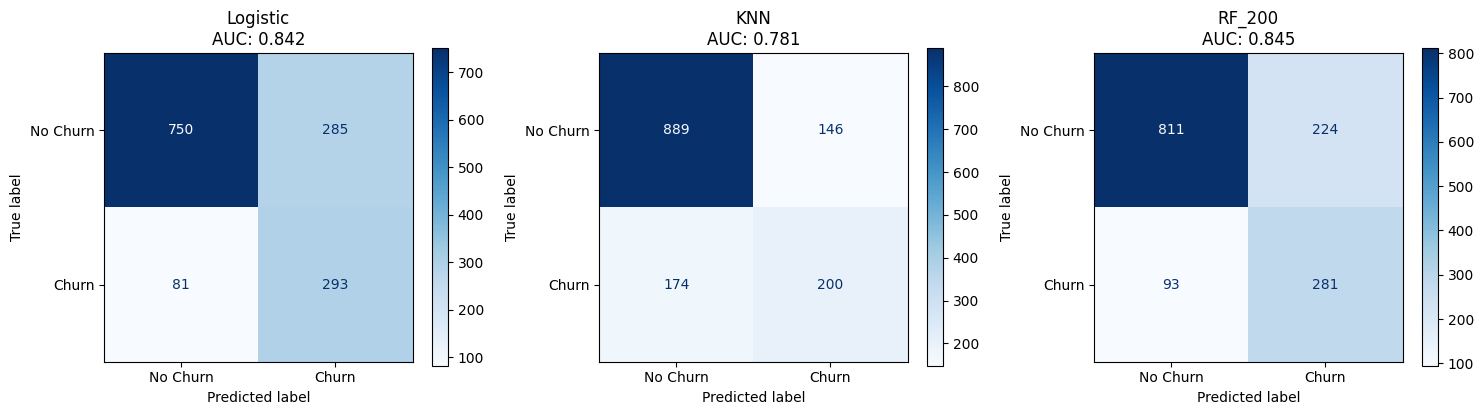

In [25]:
results = {
    'Logistic': {'pred': y_pred_lr, 'proba': y_proba_lr},
    'KNN': {'pred': y_pred_knn, 'proba': y_proba_knn},
    'RF_200': {'pred': y_pred_rf, 'proba': y_proba_rf}  }

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (modelo, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])


    print(f"\n{modelo}:")
    print(cm)


    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    auc = roc_auc_score(y_test, res['proba']).round(3)
    axes[i].set_title(f'{modelo}\nAUC: {auc}')

plt.tight_layout()
plt.show()






##¿Cuál modelo tuvo el mejor desempeño?

###Basandonos en los resultados, podemos observar que el Random Forest es el modelo que arroja resultados más optimos, aunque la diferencia entre Regresión Lineal y Random Forest es muy poca.

Sin Embargo, Random Forest presenta mejores resultados en: detección de churn, estabilidad y capacidad de capturar patrones complejos.

#Informe Final.

##Modelo Elegido


El modelo elegido para este caso es el Random Fores con 200 arboles. Ya que presento mejores resultados comparado con otros modelos, a continuación las metricas clave del modelo:

AUC 0.845:	Muy buena capacidad de separar churners de clientes normales.

F1 0.64:	Buen balance entre detectar churn y no equivocarse.

Recall: 75%	Detecta 3 de cada 4 clientes que se van a ir.

Recordemos que el objetivo final del modelo es detectar clientes antes de que se vayan.

Si bien el resultado de AUC comparado con Regresion Lineal es cercano, en las otras metricas Random Forest es superior. Lo que nos informa que es un modelo más estable.

| Modelo   | Accuracy | Precision No | Recall No | F1 No | Precision Churn | Recall Churn | F1 Churn |
| -------- | -------- | ------------ | --------- | ----- | --------------- | ------------ | -------- |
| Logistic | 0.74     | 0.90         | 0.72      | 0.80  | 0.51            | 0.78         | 0.62     |
| KNN      | 0.77     | 0.84         | 0.86      | 0.85  | 0.58            | 0.53         | 0.56     |
| RF_200   | 0.78     | 0.90         | 0.78      | 0.84  | 0.56            | 0.75         | 0.64     |

##Interpretación de las metricas.

AUC (Area Under Curve)
Mide la capacidad del modelo para distinguir entre clientes que cancelarán y los que permanecerán.
El modelo Random Forest obtuvo el mejor resultado (0.845), indicando una excelente capacidad de discriminación.

Accuracy
Representa el porcentaje total de predicciones correctas. Random Forest obtuvo el valor más alto (78%). Sin embargo, esta métrica por sí sola puede ser engañosa en datasets desbalanceados como los de churn.

Recall-Churn
Mide la proporción de clientes que realmente cancelan y que el modelo logra identificar correctamente.

Random Forest identifica el 75% de los clientes que cancelarán, mientras que Logistic Regression detecta el 78%, aunque con menor precisión global.

F1 Score
Combina precisión y recall. Random Forest obtuvo el mejor equilibrio (0.64).

#Factores principales que influyen en la cancelación:

| Variable                 | Impacto en churn | Interpretación                              |
| ------------------------ | ---------------- | ------------------------------------------- |
| Tenure                   | Muy alto         | Clientes nuevos cancelan más                |
| Tipo de contrato         | Alto             | Contratos mensuales presentan mayor churn   |
| Monthly Charges          | Alto             | Precios altos aumentan el riesgo            |
| Senior Citizen           | Medio            | Adultos mayores presentan mayor cancelación |
| Método de pago           | Medio            | Electronic check presenta mayor churn       |
| Soporte técnico          | Medio            | Falta de soporte aumenta cancelación        |
| Servicio de fibra óptica | Moderado         | Altas expectativas generan insatisfacción   |


De la tabla se puede observar que la variable "Tenure" es la que más influye en la cancelación. Es decir, los clientes con menos de 12 meses de servicio tienen una probabilidad mayor de abandonar.

La siguiente variable a considerar es "Tipo de contrato". Los clientes con contratos mensuales presentan una probabilidad mayor de cancelar el servicio. Comparado con los contratos anueales,

Se puede observar que la siguiente variable, "Cargos mensuales" tambien presentan una alta probabilidad de que los clientes cancelen el servicio. Lo que puede indicar un precio elevado vs el valor recibido por el mismo.

El hecho de que la variable "Senior Citizens" tambien tenga una alta probabilidad de churn, puede deberse a que los adultos mayores pueden presentar dificultan en el uso de la tecnologia, más frustación a las fallas del servicio o la necesidad de mayor soporte tecnico adicional.

La variable de "Metodos de Pago" arroja un alto porcentaje de clientes que cancelan, especialmente el metodo de "Electronic Check". Quizas existan problemas con este metodo de facturación.

Finalmente, la variable de "Soporte Tecnico" informa que los clientes que enfrentan problemas sin buena asistencia tienden a abandonar el servicio rapidamente.

#Estrategias de retención

##Retención de clientes nuevos

###Clientes con tenure menor a 12 meses

Acciones propuestas:

Programas de fidelización durante el primer año

Descuentos temporales en los primeros meses

Contacto proactivo con clientes nuevos

Objetivo:

Reducir la cancelación temprana durante el periodo de adopción del servicio.

-----------------------------

##Migración a contratos de mayor duración

###Clientes con contrato Month-to-Month

Acciones propuestas:

Incentivos para migrar a contratos anuales

Descuentos por permanencia

Programas de beneficios por fidelidad

Objetivo:

Reducir la flexibilidad de cancelación y aumentar la retención.

------

##Mejora del soporte técnico

Clientes con servicios tecnológicos avanzados (fibra óptica) y sin soporte técnico.

Acciones propuestas:

Paquetes de soporte técnico incluido

Atención prioritaria para problemas técnicos

Diagnóstico preventivo de servicio

Objetivo:

Reducir la frustración del cliente y mejorar la experiencia de servicio.

-----

##Simplificación de pagos

###Clientes que utilizan Electronic Check

Acciones propuestas:

Incentivos para migrar a pagos automáticos

Simplificación del proceso de facturación

Notificaciones de pago anticipadas

Objetivo:

Reducir fricciones administrativas que generan cancelación.

-----


#Conclusión final:

El estudio permitió reconocer los principales factores asociados a la cancelación de clientes, resaltando principalmente la antigüedad del cliente en la compañía, el tipo de contrato que posee y el monto de los cargos mensuales.

Entre los modelos evaluados, Random Forest con 200 árboles presentó el mejor rendimiento predictivo, alcanzando un AUC de 0.845 y logrando identificar cerca del 75% de los clientes con riesgo de cancelar el servicio.

La aplicación de este modelo facilitaría a la empresa detectar de manera anticipada a los clientes con mayor probabilidad de abandono y diseñar estrategias de retención dirigidas, contribuyendo así a disminuir la tasa de cancelación y a mejorar los ingresos en el largo plazo.